In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_SKY_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_SKY_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   


In [4]:
image_cut = image[55:155, 100:1700]

In [5]:
image_cut

array([[0.7275041 , 0.72897124, 0.7208053 , ..., 0.5063093 , 0.50589055,
        0.508855  ],
       [0.73009735, 0.72900754, 0.72074777, ..., 0.5065073 , 0.5065805 ,
        0.5091436 ],
       [0.72756875, 0.7290437 , 0.71942544, ..., 0.50636715, 0.5064969 ,
        0.5091831 ],
       ...,
       [0.72830415, 0.72906494, 0.7191505 , ..., 0.5062745 , 0.50698197,
        0.5096467 ],
       [0.7249468 , 0.72720975, 0.71817076, ..., 0.5062813 , 0.50694704,
        0.5096124 ],
       [0.7282441 , 0.72599566, 0.7192117 , ..., 0.50628835, 0.50691205,
        0.5094304 ]], dtype='>f4')

In [6]:
#prova intorno a HA_NII
#mean = np.mean(image_cut)
#std = np.std(image_cut)
#N = image_cut.shape[0] * image_cut.shape[1]
#mean_err = std / np.sqrt(N)
#print(mean)
#print(std)  #ADU
#print(mean_err)

In [7]:
mean = np.mean(image_cut)
std = np.std(image_cut)
N = image_cut.shape[0] * image_cut.shape[1]
mean_err = std / np.sqrt(N)
print(mean)
print(std)  #ADU
print(mean_err)

0.7687721
0.23309399
0.0005827349796891213


In [8]:
std*100/mean

30.32029703231297

In [9]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Propagazione_errori/mapped_std_mos.fits")
hdul2.info()
image_1 = hdul2[0].data
hdul3 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Propagazione_errori/mapped_flux_std_mos.fits")
hdul3.info()
image_2 = hdul3[0].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Propagazione_errori/mapped_std_mos.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     386   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        22   (2094, 964)   float32   
Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Propagazione_errori/mapped_flux_std_mos.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     386   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        22   (2094, 964)   float32   


In [10]:
image_m_star = image_1[0:200, 0:1890]
image_mf_star = image_2[0:200, 0:1890]

Text(0.5, 0, 'wavelength')

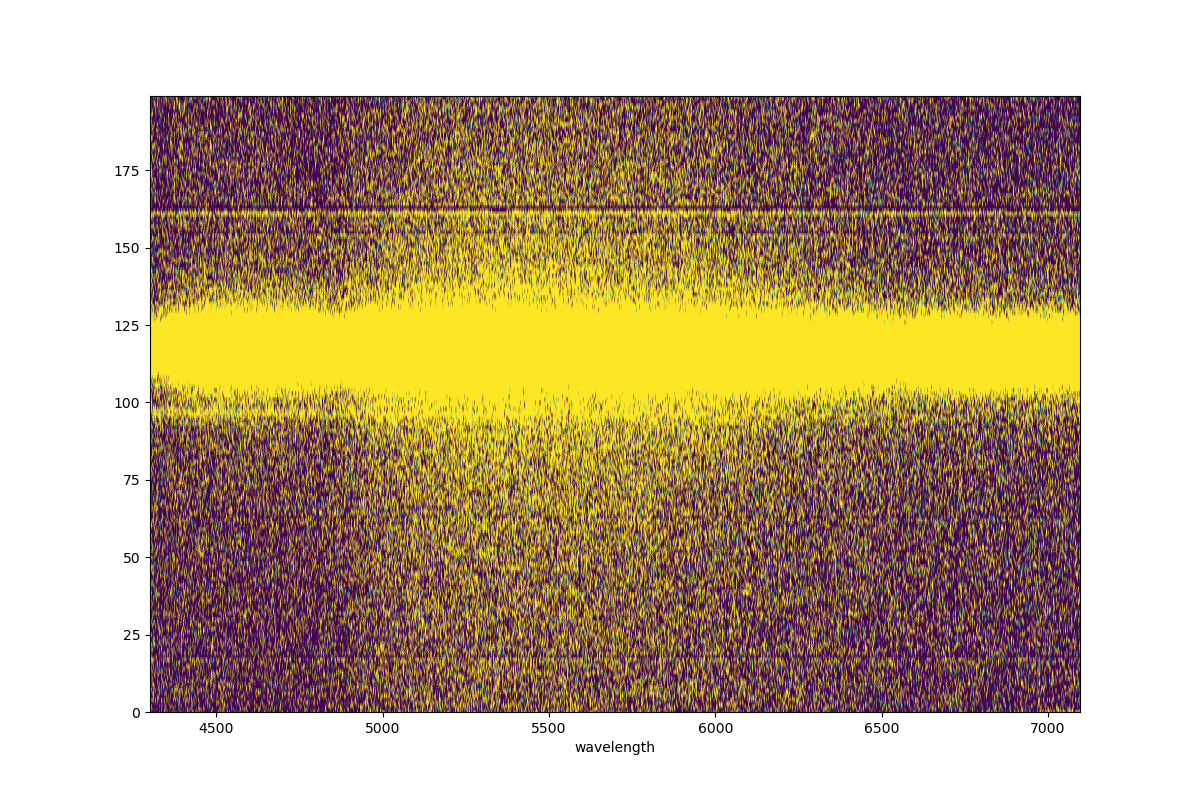

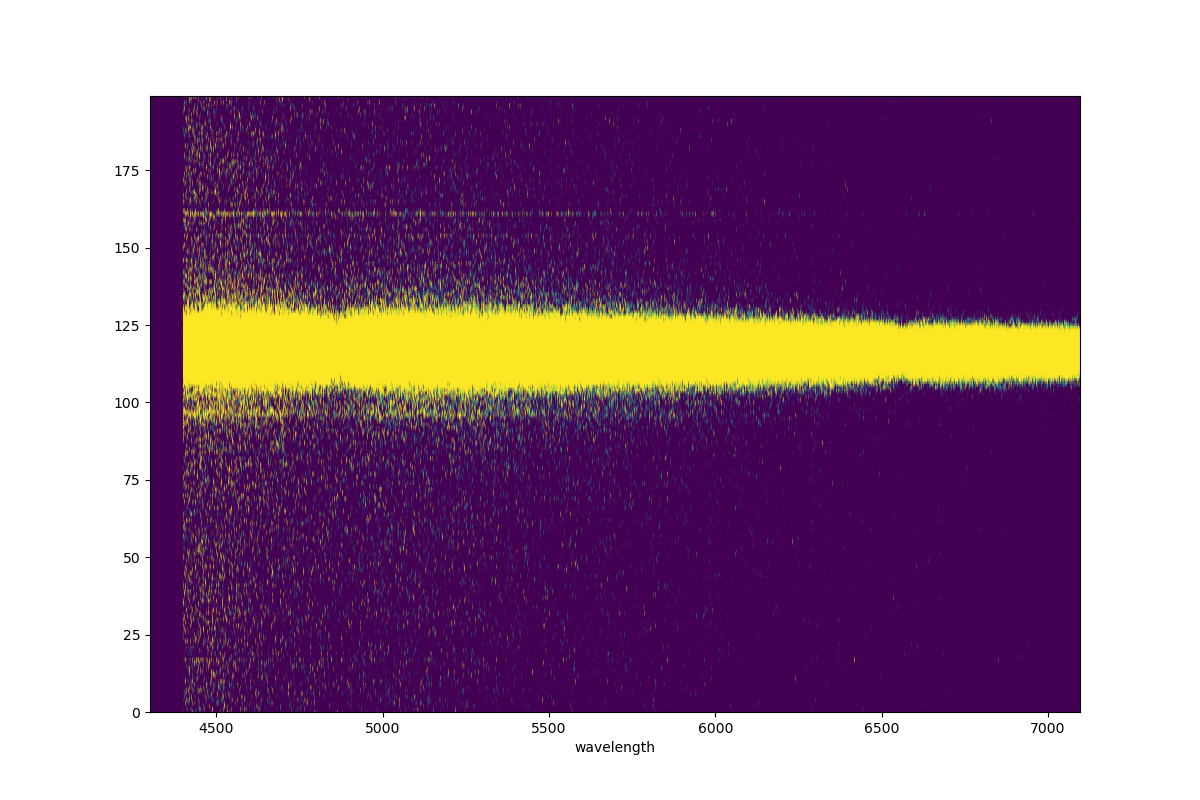

In [11]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_m_star.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
#arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(12,8))
plt.pcolormesh(x_grid, y_grid, image_m_star, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

plt.figure(figsize=(12,8))
plt.pcolormesh(x_grid, y_grid, image_mf_star, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

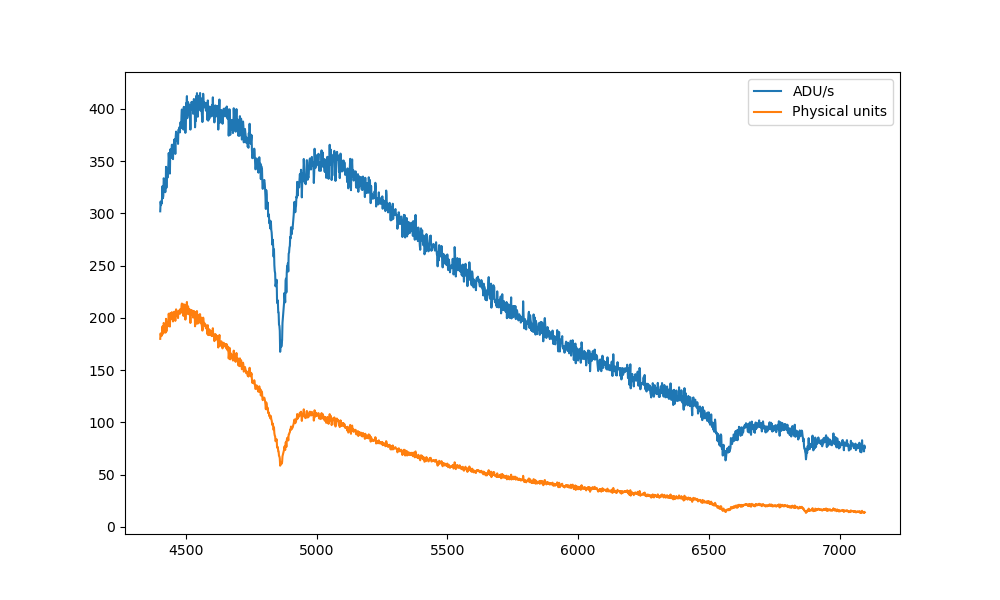

In [12]:
x_axes = np.arange(0, 200, 1)
mask = (x_axes > 119)*(x_axes < 125)
mask_wv = wv > 4400
spectrum_adu = np.sum(image_m_star[np.ix_(mask, mask_wv)], axis = 0)
spectrum_flux = np.sum(image_mf_star[np.ix_(mask, mask_wv)], axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], spectrum_adu, label = 'ADU/s')
plt.plot(wv[mask_wv], spectrum_flux, label = 'Physical units')
plt.legend()

Text(0, 0.5, 'Sensitivity')

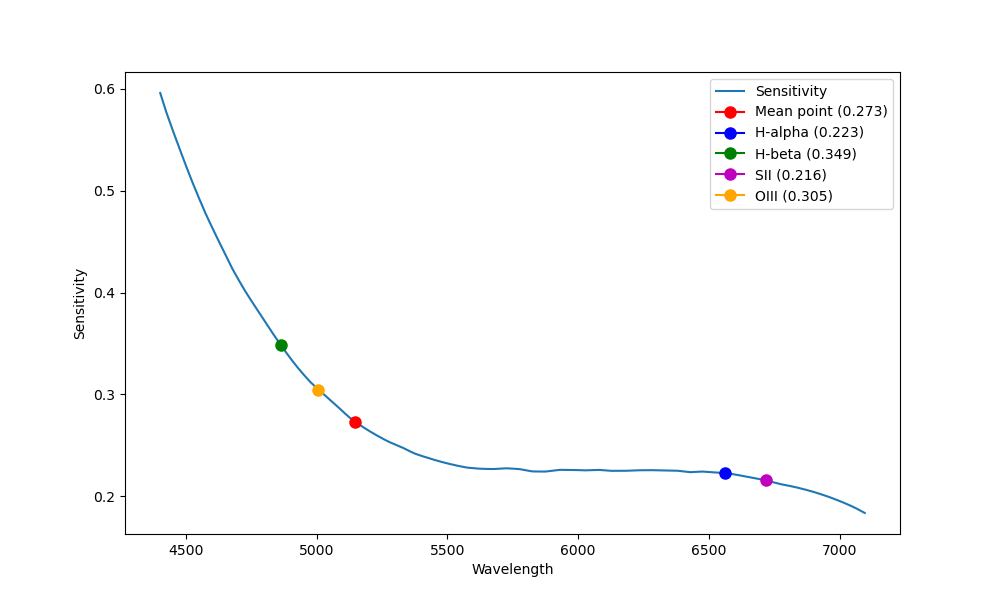

In [14]:
division = spectrum_flux/spectrum_adu
mean_value = np.mean(division)

# Trova l'indice dove division è più vicino alla media
closest_index_mean = np.argmin(np.abs(division - mean_value))

closest_index_HA = np.argmin(np.abs(wv[mask_wv] - 6563.0))
sensitivity_at_HA = division[closest_index_HA]
wavelength_at_HA = wv[mask_wv][closest_index_HA]

closest_index_HB = np.argmin(np.abs(wv[mask_wv] - 4861.0))
sensitivity_at_HB = division[closest_index_HB]
wavelength_at_HB = wv[mask_wv][closest_index_HB]

closest_index_SII = np.argmin(np.abs(wv[mask_wv] - 6717))
sensitivity_at_SII = division[closest_index_SII]
wavelength_at_SII = wv[mask_wv][closest_index_SII]

closest_index_OIII = np.argmin(np.abs(wv[mask_wv] - 5007))
sensitivity_at_OIII = division[closest_index_OIII]
wavelength_at_OIII = wv[mask_wv][closest_index_OIII]

plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], division, label='Sensitivity')
plt.plot(wv[mask_wv][closest_index_mean], division[closest_index_mean], 'red', marker='o', markersize=8, label=f'Mean point ({mean_value:.3f})')
plt.plot(wv[mask_wv][closest_index_HA], sensitivity_at_HA, 'blue', marker='o', markersize=8, label=f'H-alpha ({sensitivity_at_HA:.3f})')
plt.plot(wv[mask_wv][closest_index_HB], sensitivity_at_HB, 'green', marker='o', markersize=8, label=f'H-beta ({sensitivity_at_HB:.3f})')
plt.plot(wv[mask_wv][closest_index_SII], sensitivity_at_SII, 'm', marker='o', markersize=8, label=f'SII ({sensitivity_at_SII:.3f})')
plt.plot(wv[mask_wv][closest_index_OIII], sensitivity_at_OIII, 'orange', marker='o', markersize=8, label=f'OIII ({sensitivity_at_OIII:.3f})')
plt.legend()
plt.xlabel('Wavelength')
plt.ylabel('Sensitivity')

In [15]:
errors = np.zeros(4)
errors[0] = round(std* sensitivity_at_HB, 2)
errors[1] = round(std*sensitivity_at_OIII, 2)
errors[2] = round(std*sensitivity_at_HA, 2)
errors[3] = round(std*sensitivity_at_SII, 2)
np.savetxt('Sky_errors.txt', errors)

In [ ]:
errors

In [ ]:
#NON SERVE

In [ ]:
hdul4 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Propagazione_errori/mapped_sky_std_mos.fits")
hdul4.info()
image_3 = hdul4[0].data

In [ ]:
image_sky = image_3[5, 100:1700]

In [ ]:
mean_sky = np.mean(image_sky)
std_sky = np.std(image_sky)
N_sky = image_sky.shape[0] * image_sky.shape[1]
mean_err_sky = std_sky / np.sqrt(N_sky)
print(mean_sky)
print(std_sky)
print(mean_err_sky)

In [ ]:
mean_sky = np.mean(image_3)
std_sky = np.std(image_3)
N_sky = image_3.shape[0] * image_3.shape[1]
mean_err_sky = std_sky / np.sqrt(N_sky)
print(mean_sky)
print(std_sky)
print(mean_err_sky)

In [ ]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

In [ ]:
image_cut = image[225:355, 150:1700]

In [ ]:
np.mean(image_cut)

In [ ]:
np.std(image_cut)